# Example Notebook

In [1]:
## Import libraries
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import sys
import os

sys.path.append(os.getcwd())
from utils import load_grid_vertex, plot_map2d


In [2]:

data_root='/scratch/yanchun/cmorout'
model = 'DUMMY-MODEL'
experiment='piControl'
version='v20260601'


In [3]:
## Create some data
data_path = os.path.join(data_root, model, experiment, version)
data_file = 'masscello_tavg-ol-hxy-sea_mon_glb_g999_DUMMY-MODEL_piControl_r1i1p1f1_134101-134112.nc'
grid_file = '~/tools/data/tnx1v4/grid.nc'


In [4]:
lat, lon, clat, clon = load_grid_vertex(grid_file)
with xr.open_dataset(grid_file) as ds:
    pmask = ds['pmask']
    parea = ds['parea']

In [ ]:
#   'ocean.masscello.tavg-ol-hxy-sea.mon.glb'       ! done
#   'ocean.masso.tavg-u-hm-sea.mon.glb'             ! done


: 

In [ ]:
with xr.open_dataset(os.path.join(data_path, data_file)) as ds:
    # Assuming the variable of interest is named 'masscello'
    if 'masscello' in ds:
        masscello = ds['masscello']
    else:
        print("Variable 'masscello' not found in the dataset.")

mass2d = masscello.sum(dim='lev').isel(time=0)
mass2d = mass2d.where(pmask == 1)
#masscello.cumsum(dim='lev').plot()
#plt.xlabel("olevel")
#plt.ylabel("Cumulative masscello")
#plt.show()


In [ ]:
print(mass2d)
print(parea)

NameError: name 'mass2d' is not defined

Text(0.5, 1.0, 'Ocean Grid-Cell Mass per Area')

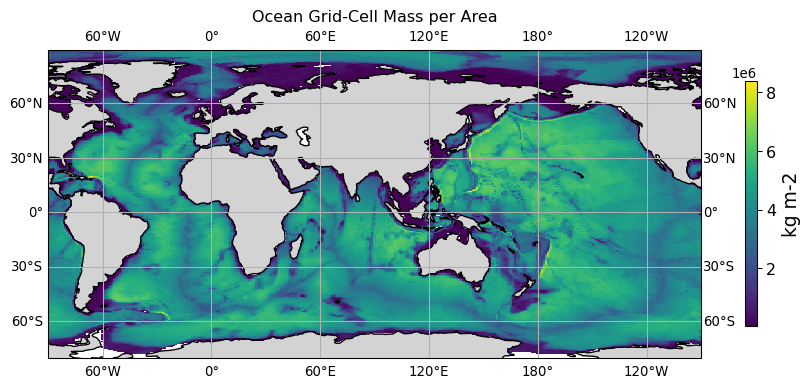

In [ ]:
fig, ax = plot_map2d(lon, lat, mass2d, proj='PlateCarree', norm=None)
ax.coastlines(resolution='110m')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
plt.title(mass2d.long_name)
